# NASDAQ-100 Microstructure: Feature Engineering

A minute bar of AlgoSeek data carries something a daily bar cannot: the state of the
order book at the close of the bar, and the side of it that the session's trades
crossed. This notebook turns those two into a feature matrix - what liquidity costs,
which way flow is leaning, how far that flow moves the price, and where in the session
the bar sits - states the window and the delay each family carries, and shows that
nothing in it reads a quote dated at or after the decision.

What makes this case study different from the daily ones is the window each statistic is
taken over. Every trailing window is bounded by the **symbol-session**, never by the symbol
alone, so no statistic spans an overnight gap; and every cross-sectional statistic is taken
over the names quoted in **that one minute**, which is the cross-section a decision is
actually taken over.

## Learning objectives

- Build quote, order-flow, price-impact and session-state features from a raw
  microstructure schema, and say which of them is a signal and which describes the state
  it is read in
- Bound every trailing window by the session, so a window never reaches across a night
- Measure the session against the exchange's **scheduled** close rather than against the
  bar count the session turned out to have, which is not knowable until it is over
- Lag an input that is published late, rather than assuming a one-minute bar is coarse
  enough to absorb the delay
- Show that withholding later dates leaves every feature value unchanged, which is what
  separates a trailing statistic from one fitted over the whole sample

## Book reference, prerequisites and artifacts

Chapter 8, Sections 8.1-8.6. Reads AlgoSeek NASDAQ-100 minute bars with the full NBBO and
trade-location schema through `load_nasdaq100_bars()`, whose coverage
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the feature specification, every window, the calendar
and the holdout boundary. Writes `features/financial.parquet` with a `.digest.json`
sidecar. [`05_evaluation`](05_evaluation.ipynb) reads its values and tests, fold by fold,
whether any of them predicts; [`04_model_based_features`](04_model_based_features.ipynb)
builds a second matrix from the same minute bars and reads this one only to confirm that
the two carry the same `symbol` and `timestamp` keys. No screen for predictive content
runs here: `05_evaluation` owns it and runs it fold-aware.

In [1]:
"""NASDAQ-100 Microstructure: Feature Engineering."""

import warnings
from datetime import date

import polars as pl
import yaml
from ml4t.diagnostic.splitters.calendar import TradingCalendar
from ml4t.engineer.features.microstructure import amihud_illiquidity

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.feature_engineering import (
    EPS,
    assert_values_agree,
    assign_families,
    families_from_config,
    family_coverage,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    warmup_audit,
)
from data import load_nasdaq100_bars
from utils.paths import display_path, get_case_study_dir

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "nasdaq100_microstructure"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
FEATURES_DIR = CASE_DIR / "features"

All three parameters are read below and all three shorten a run at the cost of a thinner
panel. `MAX_SYMBOLS` keeps a seed-deterministic subset of the universe; the two dates trim
the history. Every cross-sectional statistic in Section C ranks within one minute across
the whole universe, so a capped run computes a different quantity rather than a smaller
one - which is why CI reads the matrix for shape and never for a value.

In [2]:
MAX_SYMBOLS = 0
START_DATE = "2020-01-01"
END_DATE = "2021-12-31"

## Configuration

The feature specification, every window, the calendar and the holdout boundary are declared
in `config/setup.yaml` and bound here. A window retyped into a cell is a second source of
truth for a decision that the specification, the warmup assertion and the timing figure all
have to agree on, and the two copies drift apart the first time either is edited.

The settings below are printed as statements rather than as values, because a window is
only meaningful once you know what it decides. They fall into three groups: how often a
decision is taken, how far back each trailing statistic reads, and where the data policy
draws its lines.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
FEATURES = setup["features"]
FAMILIES = families_from_config(setup)
W = FEATURES["windows"]
PRIMARY_SIGNAL = FEATURES["carrier"]
PRIMARY_LABEL = setup["labels"]["primary"]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
DECISION_MINUTES = int(setup["decision"]["bar_frequency"].removesuffix("_minute"))
CALENDAR = setup["evaluation"]["calendar"]
UNIVERSE = sorted(setup["universe"]["symbols"])

# The panel key, the entity every trailing window is bounded by, and the partition every
# cross-sectional statistic is taken over.
PANEL_KEY = ["symbol", "timestamp"]
ENTITY = ["symbol", "session_date"]
WITHIN_MINUTE = "timestamp"

In [4]:
print(
    f"A decision is taken every {DECISION_MINUTES} minutes on the {CALENDAR} calendar, and it "
    f"is what the persistence figure measures a feature's ordering against. The label those "
    f"decisions are scored on is {PRIMARY_LABEL}, whose execution convention - which bar the "
    f"position is entered on and which one it is closed on - `02_labels` defines."
)
print(
    f"Trailing windows, in minute bars: {W['fast']} for the fastest aggregates, "
    f"{W['decision']} for one decision bar, {W['slow']} for realized volatility and for the "
    f"average of price impact per dollar traded, {W['hour']} for the impact regression and "
    f"the off-exchange share."
)
print(
    f"The {W['hour']}-bar window is the longest, so it sets the warmup every session pays "
    f"before its first row can enter the matrix."
)
print(
    f"Volatility is also carried as an exponentially weighted average with a half-life of "
    f"{W['ewma_half_life']} bars, which keeps a long window responsive to the last half hour."
)
print(
    f"Data policy: the closing bid and ask, and the size on each, are nulled once the national "
    f"best bid and offer has failed to update for more than {W['stale_cap']} consecutive bars. "
    f"The session-clock flags mark the first and last {W['edge_block']} bars of the scheduled "
    f"session."
)
print(
    f"{len(FAMILIES)} feature families are declared; the quantity the thesis puts forward is "
    f"{PRIMARY_SIGNAL}, and Sections F2, F3 and F6 read it."
)
print(
    f"The holdout begins {HOLDOUT_START}. The matrix is built across it, because the stages "
    f"that read this file need features there too, but no value on an earlier row is allowed "
    f"to depend on one inside it - Section D rebuilds the matrix from the earlier rows alone "
    f"and checks that every one of them is unchanged."
)

A decision is taken every 15 minutes on the NYSE calendar, and it is what the persistence figure measures a feature's ordering against. The label those decisions are scored on is fwd_ret_15m, whose execution convention - which bar the position is entered on and which one it is closed on - `02_labels` defines.
Trailing windows, in minute bars: 5 for the fastest aggregates, 15 for one decision bar, 30 for realized volatility and for the average of price impact per dollar traded, 60 for the impact regression and the off-exchange share.
The 60-bar window is the longest, so it sets the warmup every session pays before its first row can enter the matrix.
Volatility is also carried as an exponentially weighted average with a half-life of 30 bars, which keeps a long window responsive to the last half hour.
Data policy: the closing bid and ask, and the size on each, are nulled once the national best bid and offer has failed to update for more than 5 consecutive bars. The session-clock flags mar

## A. What the thesis says should carry information

The hypothesis is short-horizon and it is about pressure rather than value: over the next
fifteen minutes a NASDAQ-100 name drifts in the direction the last few minutes of
aggressive volume have been pushing it, and the drift is small enough that what it costs
to act on it decides whether anything is left. Three things follow.

The **quantity the thesis puts forward** is order-flow imbalance over one decision bar:
the volume that crossed the spread to buy, less the volume that crossed it to sell, as a
share of everything the bar traded. Dividing by volume makes it scale-free, so a mega-cap
and a mid-cap can sit in one ordering. The same imbalance is carried at four window
lengths rather than one, because how long aggressive flow keeps arriving is an empirical
question and not a modelling assumption; its one-bar form is also the treatment
`12_causal_dml` estimates an effect for.

The **conditioning** is everything about the environment that imbalance is read in: what
the round trip costs, how deep the book is, how far a given quantity of flow moves the
price, how much of the session is printing away from the exchanges, and where in the
session the bar sits. None of these is expected to rank names on its own, which is what
the `role` column below records and what no assertion can recover from the values.

The **window each statistic is taken over** is the symbol-session for everything trailing
and the single minute for everything cross-sectional. A spread of a cent is wide on a
hundred-dollar stock and narrow on a five-hundred-dollar one, so each level is carried
beside its z-score within the minute, and one row below claims both because they are one
hypothesis on two scales.

The table below is the **feature register**: one row per family, saying what it reads, how
far back, with what delay, and how it can fail. It is declared in `config/setup.yaml`
rather than written here, so that the warmup assertion, the timing figure and the later
stages all read the same numbers. Its rows split by **observability** rather than by
economics: the three families read off the quote feed carry no lag, and the three built
from the trade tape carry one bar, for the reason Section B gives. That is why volatility
and price impact are separate rows although they describe the same thing - a quote-based
variance is knowable at the bar it is stamped with, a traded-dollar statistic is not, and
one row cannot carry two lags.

In [5]:
register_frame(FAMILIES).select(
    ["family", "role", "inputs", "lookback (bars)", "lag (bars)", "frame"]
)

family,role,inputs,lookback (bars),lag (bars),frame
str,str,str,i64,i64,str
"""quote_liquidity""","""state""","""NBBO close quotes, quote updat…",60,0,"""per symbol-session, trailing"""
"""microprice""","""signal""","""NBBO close prices and sizes""",15,0,"""per symbol-session, trailing"""
"""volatility""","""state""","""NBBO quote midpoint and quote …",60,0,"""per symbol-session, trailing"""
"""order_flow""","""signal""","""AlgoSeek trade-location and ti…",60,1,"""per symbol-session, trailing"""
"""price_impact""","""state""","""consolidated trade prices, tra…",60,1,"""per symbol-session, trailing"""
"""hidden_liquidity""","""state""","""FINRA/TRF reported volume, tot…",60,1,"""per symbol-session, trailing"""
"""session_clock""","""state""","""exchange calendar""",0,0,"""per session, from the schedule…"


## B. Inputs and their observability

Each row is one symbol and one minute of one session. The raw AlgoSeek schema is wide -
every bar carries the open, high, low and close of both sides of the order book, the
trades that printed against it, and the time at which each of those occurred - and this
notebook reads a minority of it, in two groups. The **quote** columns describe the
national best bid and offer, the single best price available to buy and to sell across
all US exchanges at that instant. The **tape** columns describe the trades that actually
printed, split by where each one fell against that quote and by whether it was an uptick
or a downtick. The cell below prints how many of each is read; projecting them at the scan
rather than after it is what keeps a full-universe run inside a few gigabytes.

Regular hours only - the pre-market and after-hours books are thin enough that their
quotes describe a different market.

**Two inputs are not knowable at the bar they are stamped with, and each is handled here
rather than downstream.**

A quote with `nbbo_quote_count == 0` is a bar in which the NBBO never updated, so the
prices on it are carried forward from whenever it last did. One such bar is harmless; a
run of them turns a stale spread into a live-looking one and reports a calm book exactly
where the book has stopped. The **closing** bid and ask, and the size resting on each, are
nulled beyond the configured run of consecutive stale bars. That is the single data policy
the rest of the notebook inherits, and it reaches further than the four columns it names:
the midpoint is built from the closing quote, every return is a difference of midpoints,
and Section E keeps a row only where the return exists - so a bar the cap touches leaves
the matrix altogether rather than shipping with some columns filled and some empty.

FINRA/TRF prints are reported with a delay of up to ten seconds. A print executed in the
last seconds of a bar can therefore be attributed to that bar while still being unpublished
at its close.

That delay is not confined to the off-exchange share, and this is the part worth being
careful about. The trade-location and tick buckets are TRF-inclusive, so **every** feature
built from the trade tape - the order-flow shares, the traded dollars, Amihud, the trade
range - carries the same unpublished prints. Whether the vendor stamps a TRF print by
execution time or by the time it reached the tape is not documented in the data contract,
so the conservative reading is the one taken here.

Each of those features is still **computed** on the bar it describes, and only then shifted
by the lag its register row declares. The order matters: Amihud and Kyle's lambda relate a
return to the flow that moved it, so building them from a lagged tape against an unlagged
quote return would pair this bar's move with last bar's flow and measure nothing. Compute
the same-bar quantity, then publish it late.

In [6]:
OPEN_HOUR, OPEN_MINUTE, CLOSE_HOUR = 9, 30, 16
_hour, _minute = pl.col("timestamp").dt.hour(), pl.col("timestamp").dt.minute()
REGULAR_HOURS = ((_hour > OPEN_HOUR) | ((_hour == OPEN_HOUR) & (_minute >= OPEN_MINUTE))) & (
    _hour < CLOSE_HOUR
)
QUOTE_INPUTS = [
    "close_bid_price",
    "close_ask_price",
    "close_bid_size",
    "close_ask_size",
    "high_ask_price",
    "low_bid_price",
    "nbbo_quote_count",
]
# The six location buckets split a bar's volume by where each trade printed against the
# prevailing quote; the five tick buckets split the same volume by the direction of the
# print before it. Both are reconciled against the two volume columns in Section C.2.
LOCATION_BUCKETS = [
    "trade_at_bid",
    "trade_at_bid_mid",
    "trade_at_mid",
    "trade_at_mid_ask",
    "trade_at_ask",
    "trade_at_cross",
]
TICK_BUCKETS = [
    "uptick_volume",
    "downtick_volume",
    "repeat_uptick_volume",
    "repeat_downtick_volume",
    "unknown_tick_volume",
]
TAPE_INPUTS = [
    "high_trade_price",
    "low_trade_price",
    "vwap",
    "volume",
    "total_trades",
    "finra_volume",
    "finra_vwap",
    "trade_to_mid_vol_weight_rel",
    *LOCATION_BUCKETS,
    *TICK_BUCKETS,
]
READ = ["timestamp", "symbol", *QUOTE_INPUTS, *TAPE_INPUTS]

_archive = load_nasdaq100_bars(
    start_date=START_DATE,
    end_date=END_DATE,
    include_microstructure=True,
    max_symbols=MAX_SYMBOLS,
    symbols=UNIVERSE,
    lazy=True,
)
ARCHIVE_COLUMNS = _archive.collect_schema().names()
bars = (
    _archive.select(READ)
    .filter(REGULAR_HOURS)
    .with_columns(pl.col("timestamp").dt.date().alias("session_date"))
    .collect()
    .sort([*ENTITY, "timestamp"])
)

LOADER_COLS = {*READ, "session_date"}
print(
    f"{len(READ)} of the archive's {len(ARCHIVE_COLUMNS)} columns are read: "
    f"{len(QUOTE_INPUTS)} from the quote feed, {len(TAPE_INPUTS)} from the trade tape, "
    f"and the two that key the panel."
)
print(f"{bars.height:,} regular-hours bars, {bars['symbol'].n_unique()} symbols")
print(
    f"{bars['session_date'].n_unique():,} sessions, {bars['timestamp'].min()} to {bars['timestamp'].max()}"
)

28 of the archive's 63 columns are read: 7 from the quote feed, 19 from the trade tape, and the two that key the panel.
20,079,930 regular-hours bars, 115 symbols
505 sessions, 2020-01-02 09:30:00 to 2021-12-31 15:59:00


In [7]:
QUOTE_COLS = ["close_bid_price", "close_ask_price", "close_bid_size", "close_ask_size"]


def cap_stale_quotes(df: pl.DataFrame) -> pl.DataFrame:
    """Null the quote sides once the NBBO has failed to update for too many bars.

    The run length is a trailing count within the symbol-session, so a bar is judged on
    the bars before it and never on the bars after it.
    """
    cap = W["stale_cap"]
    run = (pl.col("nbbo_quote_count") == 0).cast(pl.Int32).rolling_sum(cap + 1).over(ENTITY)
    return df.with_columns(run.alias("_stale_run")).with_columns(
        pl.when(pl.col("_stale_run") > cap).then(None).otherwise(pl.col(c)).alias(c)
        for c in QUOTE_COLS
    )

In [8]:
_capped = cap_stale_quotes(bars)["_stale_run"]
print(
    f"Staleness cap: {(_capped > W['stale_cap']).sum():,} bars "
    f"({(_capped > W['stale_cap']).mean():.3%}) ran more than {W['stale_cap']} stale quotes"
)

Staleness cap: 27,716 bars (0.140%) ran more than 5 stale quotes


The session's length is taken from the exchange calendar rather than from the bars. Both
answers agree on a full session and they do not agree on an early close: the vendor emits
a padded 390-bar grid on every date, so a half-session's realized bar count says 390 where
the exchange closed after 210. Counting from the schedule is also the only form of the
quantity a trader had at the open, which is the property Section D.1 turns on.

The schedule is what decides which bars exist at all, so it is applied before anything is
built. A bar the vendor emits after the exchange has closed is not a quiet bar: its quote is
a carry-forward from before the close and no position could have been opened on it. Those
bars are dropped here rather than carried and flagged, because a feature computed on one is
a feature for a time at which no decision existed.

They are a contiguous tail of three sessions rather than holes inside them, so removing them
shortens those sessions and gaps nothing: every trailing window still reads consecutive
minutes, and `04_model_based_features` reads the same unbroken sequences.

In [9]:
_schedule = TradingCalendar(CALENDAR).calendar.schedule(start_date=START_DATE, end_date=END_DATE)
sessions = pl.DataFrame(
    {
        "session_date": [d.date() for d in _schedule.index],
        "session_bars": (
            (_schedule["market_close"] - _schedule["market_open"]).dt.total_seconds() // 60
        ).astype("int32"),
    }
)
SHORT = sessions.filter(pl.col("session_bars") < sessions["session_bars"].max())
# The join below is an inner one, so a session the panel holds and the calendar does not
# would be dropped silently and counted as padding. Bound that direction explicitly.
_unscheduled = set(bars["session_date"].unique()) - set(sessions["session_date"])
assert not _unscheduled, f"{len(_unscheduled)} session dates are not on the {CALENDAR} calendar"
print(f"{sessions.height} scheduled sessions, {SHORT.height} of them early closes")
print(f"scheduled lengths in bars: {sorted(sessions['session_bars'].unique().to_list())}")
_early = ", ".join(str(d) for d in SHORT["session_date"].to_list())
print(f"early closes: {_early or 'none in this window'}")
print(f"every one of the panel's {bars['session_date'].n_unique()} sessions is on the calendar")

505 scheduled sessions, 3 of them early closes
scheduled lengths in bars: [210, 390]
early closes: 2020-11-27, 2020-12-24, 2021-11-26


every one of the panel's 505 sessions is on the calendar


In [10]:
_minute_of_day = (
    pl.col("timestamp").dt.hour().cast(pl.Int32) * 60
    + pl.col("timestamp").dt.minute().cast(pl.Int32)
    - (OPEN_HOUR * 60 + OPEN_MINUTE)
)
_padded = bars.height
bars = (
    bars.join(sessions, on="session_date", how="inner")
    .filter(_minute_of_day < pl.col("session_bars"))
    .drop("session_bars")
    .sort([*ENTITY, "timestamp"])
)
print(
    f"{_padded - bars.height:,} bars dropped past the scheduled close on {SHORT.height} early closes"
)
print(f"{bars.height:,} bars inside scheduled hours")

54,900 bars dropped past the scheduled close on 3 early closes
20,025,030 bars inside scheduled hours


## C. Feature construction

### C.1 Quote liquidity and the microprice

The midpoint of the closing NBBO is the fair value a return is taken between, the spread
relative to it is the round trip a signal has to clear, and the depth-weighted price -
the microprice - leans toward the thin side of the book. Its **deviation** from the
midpoint is the informative quantity rather than its level (Stoikov, 2018): the level is
a price and moves with the stock, the deviation is a pressure and does not.

Every ratio here floors its denominator at the same small constant, so a bar whose book
is empty on both sides yields a bounded number rather than an infinity that would then
dominate every statistic computed downstream of it.

In [11]:
def quote_features(df: pl.DataFrame) -> pl.DataFrame:
    """Cost, depth and pressure, read off the closing NBBO of each bar."""
    bid, ask = pl.col("close_bid_price"), pl.col("close_ask_price")
    bid_size, ask_size = pl.col("close_bid_size"), pl.col("close_ask_size")
    mid = (bid + ask) / 2
    depth = (bid_size + ask_size).clip(lower_bound=EPS)
    micro = (ask * bid_size + bid * ask_size) / depth
    return df.with_columns(
        mid.alias("mid_close"),
        ((ask - bid) / mid.clip(lower_bound=EPS)).alias("rel_spread_close"),
        (micro - mid).alias("microprice_dev"),
        ((bid_size - ask_size) / depth).alias("depth_imb"),
        pl.col("nbbo_quote_count").cast(pl.Float64).alias("quote_rate"),
    )

### C.2 Order flow

AlgoSeek reports each bar's volume split by where the trade printed against the prevailing
quote, which is what makes a signed volume possible without a tick rule. Volume that
crossed at or above the midpoint was buyer-initiated and volume at or below it was
seller-initiated; the difference is aggressive net demand, and dividing it by the volume
it was measured over makes a share that ranks across the universe. The tick imbalance asks
the same question of the direction of successive prints rather than of their location.

**Which volume it is divided by is the whole of whether the result is a share.** The
location and tick buckets cover every trade in the bar, including the ones reported to the
FINRA trade reporting facility rather than to an exchange, while `volume` counts the
exchange prints alone. Dividing by `volume` would therefore divide a total by one of its
parts, and the result would run outside $[-1, 1]$ - which is not a scale. `total_trades`
counts on the same basis: a bar with no exchange volume and one off-exchange print still
reports a trade.

The cell below reconciles the buckets against both candidate denominators rather than
leaving the choice to be taken on trust. It reports how far each set of buckets exceeds
the exchange volume alone, and how closely each matches the two venues added together.

In [12]:
_location = sum(pl.col(c) for c in LOCATION_BUCKETS)
_tick = sum(pl.col(c) for c in TICK_BUCKETS)
_both_venues = pl.col("volume") + pl.col("finra_volume")
_reconciliation = bars.select(
    (_location - pl.col("volume")).max().alias("location_over_exchange"),
    (_tick - pl.col("volume")).max().alias("tick_over_exchange"),
    (_location - _both_venues).abs().max().alias("location_vs_both"),
    ((_location - _both_venues) != 0).sum().alias("location_disagreeing"),
    (_tick - _both_venues).abs().max().alias("tick_vs_both"),
)
_r = _reconciliation.row(0, named=True)
print(
    f"Against the exchange prints alone, the buckets over-count by up to "
    f"{_r['location_over_exchange']:,} shares by location and "
    f"{_r['tick_over_exchange']:,} by tick direction."
)
print(
    f"Against both venues added together, the tick buckets differ by at most "
    f"{_r['tick_vs_both']:,} shares. Of {bars.height:,} bars the location buckets disagree "
    f"on {_r['location_disagreeing']:,}, and the largest gap in shares is "
    f"{_r['location_vs_both']:,}."
)

Against the exchange prints alone, the buckets over-count by up to 12,240,025 shares by location and 12,240,025 by tick direction.
Against both venues added together, the tick buckets differ by at most 0 shares. Of 20,025,030 bars the location buckets disagree on 0, and the largest gap in shares is 0.


So the volume every share in this family is a share *of* is the exchange prints plus the
ones reported away from them, which is what the buckets themselves are counted over.

`DOLLAR_VOLUME` is the dollars behind that volume, from both venues. Each side's VWAP is
null exactly where that side traded nothing, so each product is taken as zero there and the
bar is null only when neither venue printed - the one case in which "dollars traded" has no
value rather than a small one.

In [13]:
TRADED_VOLUME = (pl.col("volume") + pl.col("finra_volume")).clip(lower_bound=1)
DOLLAR_VOLUME = (
    pl.when((pl.col("volume") + pl.col("finra_volume")) > 0)
    .then(
        pl.col("vwap").fill_null(0.0) * pl.col("volume")
        + pl.col("finra_vwap").fill_null(0.0) * pl.col("finra_volume")
    )
    .otherwise(None)
)


def order_flow_features(df: pl.DataFrame) -> pl.DataFrame:
    """Which side paid the spread, as a share of everything the bar traded."""
    signed = (pl.col("trade_at_ask") + pl.col("trade_at_mid_ask")) - (
        pl.col("trade_at_bid") + pl.col("trade_at_bid_mid")
    )
    ticked = (pl.col("uptick_volume") + pl.col("repeat_uptick_volume")) - (
        pl.col("downtick_volume") + pl.col("repeat_downtick_volume")
    )
    return df.with_columns(
        signed.alias("signed_vol"),
        ticked.alias("tick_imb_vol"),
        (signed / TRADED_VOLUME).alias("signed_vol_share"),
        (ticked / TRADED_VOLUME).alias("tick_imb_share"),
        pl.col("trade_to_mid_vol_weight_rel").alias("trade_to_mid_rel"),
        (pl.col("total_trades") / TRADED_VOLUME * 1000).alias("trades_per_1k_shares"),
        (pl.col("trade_at_cross") / TRADED_VOLUME).alias("cross_locked_share"),
    )

### C.3 Volatility, range and price impact

Returns are taken between quote midpoints rather than between trade prices, because a
trade series alternates between the bid and the ask as buyers and sellers arrive and a
return taken across that alternation carries a bounce with no information in it
(Hasbrouck, 2007). Realized volatility at three horizons and an EWMA of the same series
describe how much uncertainty a signal is being read against.

Two impact measures answer the same question on different data. **Amihud illiquidity**
(Amihud, 2002) is the *average*, over a trailing window, of the absolute return per dollar
traded, and the library's estimator is what computes it here. Averaging is what makes it a
statement about how deep the market for a name is rather than about one bar: a single
bar's ratio of return to dollars is dominated by whichever bar happened to trade thinnest,
and carries a different scale. On a bar that printed no trades the ratio itself is
undefined, because price impact per dollar traded means nothing when nothing traded; the
estimator drops that bar from the window it averages rather than emptying the window, so
the feature is null only where no bar in the window traded. **Kyle's lambda**
regresses the return on the signed share over a rolling hour
and is kept local: the identity form below has a warmup of exactly its window where a
two-pass covariance would need twice that.

**Dollar volume counts both venues, for the same reason the order-flow denominator does.**
`vwap` and `volume` describe the exchange prints alone, and a bar whose trades all printed
to the TRF would otherwise report no dollars traded and no price impact - which is not that
the bar was quiet but that this notebook was looking at one venue. The two venues' dollars
are added, and the price Amihud is given is the volume-weighted average across both, so
each venue's shares are priced at the average they actually traded at.

In [14]:
def volatility_features(df: pl.DataFrame) -> pl.DataFrame:
    """Uncertainty and price impact, over windows bounded by the session."""
    ret = pl.col("mid_close").log().diff().over(ENTITY)
    df = df.with_columns(ret.alias("r1m"))
    return df.with_columns(
        *[
            pl.col("r1m").rolling_std(w).over(ENTITY).alias(f"rv_{w}m")
            for w in (W["fast"], W["decision"], W["slow"])
        ],
        pl.col("r1m")
        .pow(2)
        .ewm_mean(half_life=W["ewma_half_life"])
        .over(ENTITY)
        .sqrt()
        .alias(f"rv_ewma_{W['ewma_half_life']}m"),
        (pl.col("high_trade_price").log() - pl.col("low_trade_price").log()).alias("trade_range"),
        (pl.col("high_ask_price").log() - pl.col("low_bid_price").log()).alias("quote_range"),
        DOLLAR_VOLUME.alias("dollar_vol"),
        amihud_illiquidity(
            returns=pl.col("r1m"),
            volume=TRADED_VOLUME,
            price=DOLLAR_VOLUME / TRADED_VOLUME,
            period=W["slow"],
        )
        .over(ENTITY)
        .alias("illiq"),
    )

In [15]:
def kyle_lambda(df: pl.DataFrame) -> pl.DataFrame:
    """Price impact per unit of signed order flow, over a rolling hour (Kyle, 1985).

    Built from the single-pass identities cov(r, s) = E[rs] - E[r]E[s] and
    var(s) = E[s^2] - E[s]^2, so the warmup is exactly the window rather than twice it.
    """
    window = W["hour"]
    r, s = pl.col("r1m"), pl.col("signed_vol_share")
    return (
        df.with_columns(
            r.rolling_mean(window).over(ENTITY).alias("_r"),
            s.rolling_mean(window).over(ENTITY).alias("_s"),
            (r * s).rolling_mean(window).over(ENTITY).alias("_rs"),
            s.pow(2).rolling_mean(window).over(ENTITY).alias("_ss"),
        )
        .with_columns(
            (
                (pl.col("_rs") - pl.col("_r") * pl.col("_s"))
                / (pl.col("_ss") - pl.col("_s").pow(2)).clip(lower_bound=EPS)
            ).alias("kyle_lambda")
        )
        .drop("_r", "_s", "_rs", "_ss")
    )

### C.4 Hidden liquidity and the session clock

The FINRA share is the fraction of a bar's volume that printed away from the exchanges. It
is computed on its own bar like everything else and shifted afterwards, along with the two
other trade-derived families, by `publish_with_lag`.

The session clock says where in the day a bar sits, as a fraction of the session. Both
halves of that fraction come from the clock and from the exchange's published schedule, so
both are knowable before the session opens. The obvious alternative is to divide by the
number of bars the session turned out to have, and it fails silently: that count is an
aggregate over the whole symbol-session, so nobody holds it until the session is over, and
a feature built on it is a quantity that did not exist when the decision was taken. The
block flags mark the configured window at each end of the scheduled session, so a bar the
vendor emits after an early close falls in neither.

In [16]:
def regime_and_clock_features(df: pl.DataFrame) -> pl.DataFrame:
    """The slow off-exchange regime, and where in the scheduled session a bar sits."""
    finra = pl.col("finra_volume") / TRADED_VOLUME
    # `dt.hour()` and `dt.minute()` are Int8, and Int8 arithmetic wraps rather than raising:
    # 9 * 60 is 28, not 540. Both are widened before the multiplication.
    hour = pl.col("timestamp").dt.hour().cast(pl.Int32)
    minute = pl.col("timestamp").dt.minute().cast(pl.Int32)
    bar = hour * 60 + minute - (OPEN_HOUR * 60 + OPEN_MINUTE)
    length = pl.col("session_bars")
    edge = W["edge_block"]
    return df.with_columns(
        finra.rolling_mean(W["hour"]).over(ENTITY).alias("finra_share_60m"),
        bar.alias("bar_of_day"),
        (bar / length).clip(0.0, 1.0).alias("time_since_open"),
        (1.0 - bar / length).clip(0.0, 1.0).alias("time_to_close"),
        (bar < edge).cast(pl.Float64).alias("is_first_30m"),
        ((bar >= length - edge) & (bar < length)).cast(pl.Float64).alias("is_last_30m"),
    )

### C.5 Multi-resolution aggregates and the cross-section

Microstructure signals decay at different rates - an order-flow imbalance reverts within
minutes while a spread dislocation persists - so the fast families are carried at the
fast, decision and hourly windows and the model is left to learn which horizon holds the
content. The aggregates are ratios of sums rather than means of ratios: over five bars the
question is what share of the *volume traded in those five minutes* was aggressive, which a
mean of five per-bar shares answers only when the five bars carried equal volume.

The cross-sectional z-score is taken **within the minute**, over the names quoted in it,
which is the cross-section a decision is taken over and the only partition that removes a
market-wide move without reaching across time. It is a representation of the same
hypothesis rather than a new one, which is why one register row claims a level and its
z-score together.

Each entry below is one source column, the stem its aggregates are named on, and the
windows. `SHARES` divides a sum by the volume traded over the same window; `MEANS` averages
a quantity that is already a ratio.

In [17]:
SHARES = {
    "signed_vol": ("signed_vol_share", (W["fast"], W["decision"], W["hour"])),
    "tick_imb_vol": ("tick_imb_share", (W["fast"], W["decision"])),
}
MEANS = {
    "rel_spread_close": ("rel_spread", (W["fast"], W["decision"], W["hour"])),
    "trade_to_mid_rel": ("trade_to_mid", (W["fast"],)),
    "microprice_dev": ("microprice_dev", (W["fast"], W["decision"])),
}


def multi_resolution(df: pl.DataFrame) -> pl.DataFrame:
    """The fast families again, over the fast, decision and hourly windows."""
    return df.with_columns(
        [
            (
                pl.col(source).rolling_sum(w).over(ENTITY)
                / TRADED_VOLUME.rolling_sum(w).over(ENTITY)
            ).alias(f"{stem}_{w}m")
            for source, (stem, windows) in SHARES.items()
            for w in windows
        ]
        + [
            pl.col(source).rolling_mean(w).over(ENTITY).alias(f"{stem}_{w}m")
            for source, (stem, windows) in MEANS.items()
            for w in windows
        ]
    )

The z-score partition is the minute alone. Which columns get one is derived from the
register rather than listed again here: every level a family claims is ranked, except the
session clock, whose values are identical across the cross-section by construction and
whose z-score would therefore be a column of zeros divided by nothing.

The intermediates listed below are what the families are assembled from, and no model may
read them: a contemporaneous price or an unnormalized volume beside a label derived from
the same midpoint series is a model reading its own answer.

In [18]:
INTERMEDIATE = {
    "mid_close",
    "signed_vol",
    "tick_imb_vol",
    "bar_of_day",
    "session_bars",
    "_stale_run",
}
RANKED_FAMILIES = [f.name for f in FAMILIES if f.name != "session_clock"]
LAGGED_FAMILIES = {f.name for f in FAMILIES if f.lag > 0}


def publish_with_lag(df: pl.DataFrame) -> pl.DataFrame:
    """Shift each family's levels by the lag its register row declares.

    Every feature is computed on the bar it describes, so a price-impact estimator
    relates a return to the flow that moved it rather than to the previous bar's flow.
    The shift is applied afterwards, to the finished quantity, which is what "published
    late" means: the value is about bar t and it is not readable until t + lag.

    Shifting the finished feature and shifting its inputs are the same thing for a
    trailing window over one entity, and they are not the same thing for anything that
    reads two sources. That is the whole of this function's reason to exist.
    """
    levels = [c for c in df.columns if c not in LOADER_COLS and c not in INTERMEDIATE]
    claimed = assign_families(levels, FAMILIES)
    lag = {f.name: f.lag for f in FAMILIES}
    return df.with_columns(
        pl.col(c).shift(lag[family]).over(ENTITY)
        for c, family in claimed.items()
        if family in LAGGED_FAMILIES
    )


def cross_sectional(df: pl.DataFrame) -> pl.DataFrame:
    """The z-score of each level within its own minute, across the quoted universe."""
    levels = [c for c in df.columns if c not in LOADER_COLS and c not in INTERMEDIATE]
    claimed = assign_families(levels, FAMILIES)
    columns = sorted(c for c, family in claimed.items() if family in RANKED_FAMILIES)
    return df.with_columns(
        (
            (pl.col(c) - pl.col(c).mean().over(WITHIN_MINUTE))
            / pl.col(c).std().over(WITHIN_MINUTE).clip(lower_bound=EPS)
        ).alias(f"{c}_xs")
        for c in columns
    )

The six subsections compose into one function, which is what lets D.3 re-run the whole
construction on a shorter panel and compare. The scheduled session length is joined before
the clock family is built, because that family is a statement about the exchange's day
rather than about the panel's rows.

In [19]:
def build_features(bars: pl.DataFrame) -> pl.DataFrame:
    """Every family, in dependency order, on a panel sorted by symbol-session and time."""
    return (
        bars.join(sessions, on="session_date", how="left")
        .pipe(cap_stale_quotes)
        .pipe(quote_features)
        .pipe(order_flow_features)
        .pipe(volatility_features)
        .pipe(kyle_lambda)
        .pipe(regime_and_clock_features)
        .pipe(multi_resolution)
        .pipe(publish_with_lag)
        .pipe(cross_sectional)
        .drop("_stale_run")
    )

In [20]:
built = build_features(bars)
feature_cols = sorted(c for c in built.columns if c not in LOADER_COLS and c not in INTERMEDIATE)
assignment = assign_families(feature_cols, FAMILIES)
print(f"{built.height:,} rows carrying {len(feature_cols)} features in {len(FAMILIES)} families")

20,025,030 rows carrying 66 features in 7 families


A share of a volume cannot exceed that volume, at any of the four windows. This is the
assertion the previous denominator failed, and it is cheaper than the figure that
eventually showed it.

In [21]:
SHARE_COLUMNS = [
    c
    for c in feature_cols
    if c.startswith(("signed_vol_share", "tick_imb_share")) and not c.endswith("_xs")
]
_worst = built.select(pl.max_horizontal([pl.col(c).abs().max() for c in SHARE_COLUMNS])).item()
assert _worst <= 1.0, f"an order-flow share reached {_worst:.1f}, so its denominator is a part"
print(f"{len(SHARE_COLUMNS)} order-flow shares, largest magnitude {_worst:.4f}")

7 order-flow shares, largest magnitude 1.0000


## D. The timing contract

### D.1 What each construction reads

Four kinds of operation appear above. A **rolling** window - every realized volatility, every
multi-resolution aggregate, the Amihud average and the four moments Kyle's lambda is built
from - ends at its own bar and reads a fixed number of earlier bars **within one
symbol-session**, so none of them spans a night. A **shift** appears twice and means two
different things: inside a construction it differences a series, and in `publish_with_lag`
it defers a finished value to the bar at which it could be read. A **contemporaneous**
relation - the spread, the depth imbalance, the microprice deviation, the quote range -
reads one bar's own quote and no other bar at all. A **cross-sectional** statistic - the
z-scores - is taken with `.over("timestamp")`, so it reads every symbol quoted in that
minute and nothing dated before or after it, and it runs after the publication shift so a
minute's cross-section is ranked on what was readable in it.

**Three families are deferred and three are not, and the split is the register's.** Quote
liquidity, the microprice and volatility read the quote feed, which is on the wire the
moment it moves. Order flow, price impact and hidden liquidity read the trade tape, which
carries off-exchange prints that may not be published yet - so the trade range is deferred
with them, and it is the one of the two ranges that is not contemporaneous.

The session clock is the fifth kind of operation. It reads the exchange's published
schedule, which is knowable before the session opens, and no row of the panel enters it at
all. None of the five is fitted - no bound, scaler or encoder here has a parameter
estimated once and applied to every row. D.2 checks the windows; D.3 checks all five at
once.

### D.2 Warmup

A trailing window cannot produce a value until it has enough bars to fill, and because the
entity is the symbol-session every window warms up again each morning. The audit checks
that length rather than describing it: a column carrying a value before its window could
have filled is reading bars that do not exist, and that is what it raises on. The counts
below are one greater than each window wherever the input is itself a difference, because
a session's first bar has no previous bar to difference against.

In [22]:
warmup_audit(
    built,
    {
        "kyle_lambda": W["hour"] + 1,
        "finra_share_60m": W["hour"] + 1,
        "signed_vol_share_60m": W["hour"],
        "rel_spread_60m": W["hour"],
        "illiq": W["slow"] + 1,
        f"rv_{W['slow']}m": W["slow"] + 1,
        f"rv_{W['decision']}m": W["decision"] + 1,
        "microprice_dev_15m": W["decision"],
        f"rv_{W['fast']}m": W["fast"] + 1,
        "r1m": 2,
    },
    entity=ENTITY,
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""kyle_lambda""",61,62,true
"""finra_share_60m""",61,61,true
"""signed_vol_share_60m""",60,61,true
"""rel_spread_60m""",60,60,true
"""illiq""",31,31,true
"""rv_30m""",31,31,true
"""rv_15m""",16,16,true
"""microprice_dev_15m""",15,15,true
"""rv_5m""",6,6,true


### D.3 Withholding the holdout changes nothing

Trailing, contemporaneous and within-minute statistics share a property worth checking
directly: recomputed on a panel that stops before the holdout, they reproduce the same
values on the rows the two panels share. A parameter fitted over a whole column does not,
because truncating the column moves the parameter and with it every row it was applied to.
Comparing two builds tests every emitted column at once and does not depend on anyone
having flagged the transform that fits. A value on one side against a null on the other
counts as a difference.

The cross-sectional z-score is the column this check exists for. It is taken within a
minute, so truncating the panel at a date removes whole minutes and leaves the surviving
ones with the same membership. A z-score taken over the whole sample is the transform this
check is built to catch: truncating the panel moves its mean and standard deviation, and
with them every row.

In [23]:
_before = pl.col("timestamp").dt.date() < HOLDOUT_START
_emitted = [*PANEL_KEY, *feature_cols]
pre_holdout = built.filter(_before).select(_emitted)
# Withholding rows tests something only if there are rows to withhold. On a panel that stops
# before the boundary the two builds are the same rows, and the comparison below passes
# without anything having been held back.
assert pre_holdout.height < built.height, (
    "no row falls on or after the holdout, so this comparison withholds nothing"
)
agreement = assert_values_agree(
    pre_holdout,
    build_features(bars.filter(_before)).select(_emitted),
    columns=feature_cols,
    keys=PANEL_KEY,
)
agreement.filter(pl.col("column").is_in(["kyle_lambda", f"{PRIMARY_SIGNAL}_xs", "finra_share_60m"]))

column,rows compared,null only on one side,max abs difference
str,i64,i64,f64
"""finra_share_60m""",15055320,0,0.0
"""kyle_lambda""",15055320,0,0.0
"""signed_vol_share_15m_xs""",15055320,0,0.0


## E. Matrix assembly and coverage

The panel key is `symbol` + `timestamp`. Everything the loader supplied is excluded - the
quote sides and sizes, the trade-location buckets, volume, the VWAP and the quote count -
because a model handed a contemporaneous price beside a label derived from the same
midpoint series would be reading its own answer. The five intermediates the families are
assembled from go with them.

One null policy is applied once: a row is kept when the one-minute return, the realized
volatility and Kyle's lambda - the three columns the volatility and impact family is gated
on - have all warmed up, of which Kyle's lambda at an hour is the binding one. Requiring it
subsumes every shorter window in that family, and the longer families of Section C.5 fill
in at the same bar, which is what F1 shows.

What the policy keeps is not everywhere dense, and the gaps are all of one kind. A bar on
which neither venue printed has no dollar volume, no Amihud value and no volume-weighted
trade-to-mid distance; and because the Amihud average nulls a whole window for one missing
bar, a small share of such bars costs far more rows than it occupies. The results cell
below reports both. Those rows keep a null rather than a fabricated number, which is what
F1 shows as the shortfall in the two trade-derived families.

The policy also costs one feature outright, and the arithmetic below states it rather than
leaving it to be discovered. Kyle's lambda needs an hour of bars, so the matrix begins an
hour into every session, while `is_first_30m` marks the first half hour - so every bar the
flag could be true of has already been dropped, and the column ships identically zero. It
is kept because it is one of the four flags and fractions the session-clock family is
defined as, and the assertion below records that it carries nothing here rather than
leaving a reader to find that out from a model.

The emitted features are Float32, not Float64. A minute panel of 16.9 million rows and 66
feature columns is 8.9 GB of Float64 and 4.5 GB of Float32, and every consumer holds the
whole thing in memory before it fits anything. Float32 carries about seven decimal digits,
which is more than any quantity here is determined to: these are ratios, rank-normalized
cross-sections and rolling moments of prices quoted to the cent. The precision that is
actually load-bearing is spent earlier, inside the rolling sums the features are built
from, and those still run in Float64 - only the emitted result is narrowed. Estimators that
need Float64 upcast on their own, once, instead of every consumer paying for it on disk and
in the panel.

In [24]:
WARMUP_GATE = ["r1m", f"rv_{W['slow']}m", "kyle_lambda"]
features = (
    built.select([*PANEL_KEY, *feature_cols])
    .drop_nulls(subset=WARMUP_GATE)
    .sort(PANEL_KEY)
    .with_columns(pl.col(feature_cols).cast(pl.Float32))
)
assert features.select(PANEL_KEY).is_duplicated().sum() == 0, "duplicate panel key"
assert {features.schema[c] for c in feature_cols} == {pl.Float32}, "features must emit Float32"

No emitted feature may be constant without the notebook saying why. A column with one value
ranks nothing and conditions nothing, and a clipped expression is where that hides best: a
`.clip(0, 1)` turns an arithmetic mistake anywhere upstream of it into a plausible constant
rather than into an error. Nothing else here would catch it, either - a constant column
warms up on time, reproduces exactly when later dates are withheld, and carries no nulls -
so the check is made explicitly.

In [25]:
DEAD_BY_WARMUP = ["is_first_30m"]
assert W["hour"] >= W["edge_block"], "the open block is inside the warmup only if it is shorter"
assert features["is_first_30m"].max() == 0, "the open block survived a 60-bar warmup"
_variety = features.select(pl.col(c).n_unique().alias(c) for c in feature_cols)
_flat = [c for c in feature_cols if _variety[c][0] <= 1 and c not in DEAD_BY_WARMUP]
assert not _flat, f"features that take a single value across the emitted matrix: {_flat}"
print(f"{len(feature_cols) - len(DEAD_BY_WARMUP)} features vary; {DEAD_BY_WARMUP} dead by warmup")
# The decision grid the strategy rebalances on, which F3 and F6 read. A figure drawn on
# every minute would describe a cadence no decision is taken at.
DECISION_TIMES = (
    features.filter(pl.col("timestamp").dt.minute() % DECISION_MINUTES == 0)["timestamp"]
    .unique()
    .sort()
)
decisions = features.filter(pl.col("timestamp").is_in(DECISION_TIMES))
register_frame(FAMILIES, feature_cols).select(["family", "columns", "role", "representation"])

65 features vary; ['is_first_30m'] dead by warmup


family,columns,role,representation
str,i64,str,str
"""quote_liquidity""",12,"""state""","""level and cross-sectional z-sc…"
"""microprice""",6,"""signal""","""level and cross-sectional z-sc…"
"""volatility""",12,"""state""","""level and cross-sectional z-sc…"
"""order_flow""",22,"""signal""","""level and cross-sectional z-sc…"
"""price_impact""",8,"""state""","""level and cross-sectional z-sc…"
"""hidden_liquidity""",2,"""state""","""level and cross-sectional z-sc…"
"""session_clock""",4,"""state""","""fraction of the session and bl…"


In [26]:
WARMUP_BARS = max(f.lookback for f in FAMILIES)
coverage = family_coverage(features, assignment, every="1mo")
dropped = built.height - features.height
print(
    f"{len(feature_cols)} features, {features.height:,} rows, {features['symbol'].n_unique()} symbols"
)
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}, warmup {WARMUP_BARS} bars")
print(f"{dropped:,} rows dropped by the null policy ({dropped / built.height:.1%})")
print(f"thinnest family-month {min(coverage[c].min() for c in set(assignment.values())):.3f}")
print(f"{len(DECISION_TIMES):,} decision minutes carrying {decisions.height:,} rows")
# What a bar with no prints on either venue costs: it defines no dollar volume itself, and
# it nulls the whole Amihud window that contains it.
_untraded = features["dollar_vol"].null_count() / features.height
print(
    f"bars with no prints {_untraded:.2%} of rows, but illiq null on {features['illiq'].null_count() / features.height:.2%}"
)

66 features, 16,871,167 rows, 115 symbols
2020-01-02 10:31:00 to 2021-12-31 15:59:00, warmup 60 bars
3,153,863 rows dropped by the null policy (15.7%)
thinnest family-month 0.996
10,562 decision minutes carrying 1,076,821 rows
bars with no prints 0.05% of rows, but illiq null on 0.00%


The matrix carries **66 features** on **16,871,167 rows** across **115 symbols** and **505
sessions**, from **2020-01-02 10:31** to **2021-12-31 15:59**. The null policy dropped
**3,153,863 rows**, **15.7%**, which is the hour of warmup every session pays before Kyle's
lambda exists plus the bar its publication lag costs - and it is why the panel starts at
10:31 rather than at the open. The
thinnest family-month is **0.996** covered, in the price-impact family. Of those
rows, **1,076,821** fall on the **10,562** minutes of the 15-minute decision grid, which is
the subset F3 and F6 read.

Bars on which neither venue printed are **0.05%** of the matrix and leave **0.00%** of it
without an Amihud value. Amihud (2002) averages the ratio over the periods that traded, so a
bar with no prints leaves the window rather than emptying it; a plain rolling average would
instead propagate that gap across all thirty bars whose window contains it.

### F1. Coverage through time

The warmup here is intraday rather than historical - it is paid again every morning, and it
is already spent by the time a row reaches the matrix at all - so the boundary sits at the
panel's first month rather than a year into it, and no family ever climbs into place. The
axis is drawn on the range the data occupies rather than on nought to one, because the
whole of what this figure has to show sits in its top sliver.

The split it shows is the register's own. Five of the seven families are complete on every
row: the three read off the quote feed, the session clock, and the smoothed off-exchange
share, which is a ratio of two volumes that are never both absent. The two read off the
trade tape are not, because a bar on which neither venue printed defines none of them.

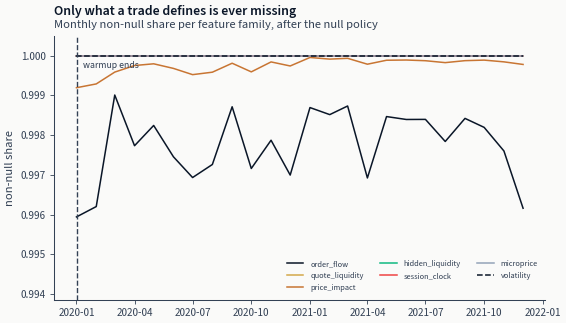

In [27]:
plot_coverage_through_time(
    coverage,
    warmup_boundary=features["timestamp"].min(),
    title="Only what a trade defines is ever missing",
    subtitle="Monthly non-null share per feature family, after the null policy",
    alt=(
        "Line chart of non-null share by feature family by month, on a y-axis spanning "
        "roughly 0.990 to 1.0. Five families - quote liquidity, microprice, volatility, hidden "
        "liquidity and session clock - lie exactly on one for the whole sample, drawn on top "
        "of each other as a single flat line at the top. The order flow family runs below it "
        "between about 0.9957 and 0.9990, and the price impact family is the lowest and most "
        "ragged, between about 0.9913 and 0.9993, dipping hardest in the first month and "
        "again in mid-2020. The two lower lines track each other closely and both fall away "
        "in the final month."
    ),
)

### F4. The timing contract

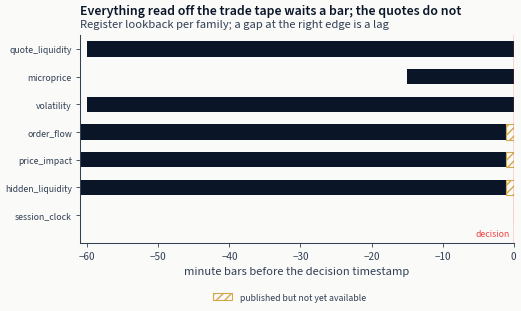

In [28]:
plot_timing_contract(
    FAMILIES,
    bar_unit="minute bars",
    title="Everything read off the trade tape waits a bar; the quotes do not",
    subtitle="Register lookback per family; a gap at the right edge is a lag",
    alt=(
        "Horizontal bars, one per feature family, each extending leftward from the decision "
        "line by that family's lookback: 60 minute bars for quote liquidity, volatility, "
        "order flow, price impact and hidden liquidity, 15 for the microprice family, and "
        "none for the session clock. The quote liquidity, volatility and microprice bars run "
        "flush to the decision line. The order flow, price impact and hidden liquidity bars "
        "each stop one bar short of it, and the gap is hatched - the delay with which a "
        "TRF print becomes public."
    ),
)

## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature
arrives on, whether the cross-section disagrees enough to rank on, how much of the set is
one ordering under several names, and how long a value lasts. Whether any of it predicts is
`05_evaluation`'s question, and it is asked there fold by fold rather than here on the
whole sample.

### F2. Feature distributions

The order-flow family is shown on the scale a reader would judge it: the per-bar imbalance,
the same quantity over the fast, decision and hourly windows, and the decision-window
version in its cross-sectional form. Aggregating over more bars pulls the share toward
zero, and the z-score puts a bounded, heavily-tied quantity onto an unbounded one - which
is the point of carrying both.

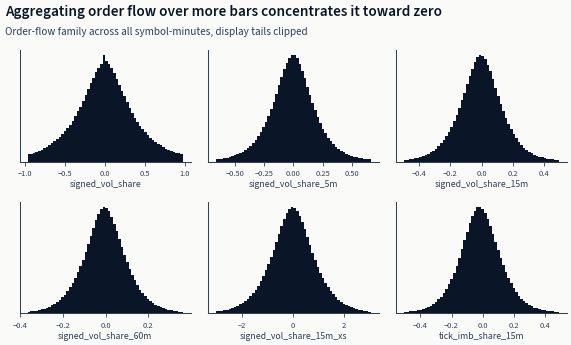

In [29]:
plot_feature_distributions(
    features,
    [
        "signed_vol_share",
        "signed_vol_share_5m",
        PRIMARY_SIGNAL,
        "signed_vol_share_60m",
        f"{PRIMARY_SIGNAL}_xs",
        "tick_imb_share_15m",
    ],
    title="Aggregating order flow over more bars concentrates it toward zero",
    subtitle="Order-flow family across all symbol-minutes, display tails clipped",
    alt=(
        "Six histograms in two rows. The per-bar signed volume share fills its full range "
        "from minus one to one, a broad symmetric peak at zero with tails that reach the "
        "bounds. The five-minute, fifteen-minute and sixty-minute aggregates are the same "
        "shape over progressively narrower ranges - about plus or minus 0.75, 0.5 and 0.3 - "
        "so each is a taller, tighter bell than the one before it. The cross-sectional "
        "z-score of the fifteen-minute share spans about minus three to three, and the "
        "fifteen-minute tick imbalance is close to its signed-volume twin."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a minute where the band
narrows to nothing there is nothing to rank, whatever the average level of order flow. This
reads the decision grid alone: a band drawn over every minute would describe a cadence no
decision is taken at.

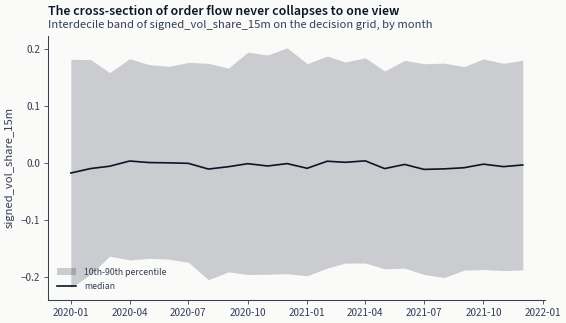

In [30]:
plot_cross_sectional_dispersion(
    decisions,
    PRIMARY_SIGNAL,
    every="1mo",
    title="The cross-section of order flow never collapses to one view",
    subtitle=f"Interdecile band of {PRIMARY_SIGNAL} on the decision grid, by month",
    alt=(
        "Shaded band of the 10th to 90th percentile of the fifteen-minute signed volume "
        "share across the universe, by month, with the median drawn through it. The median "
        "runs flat along zero for the whole sample. The band is roughly symmetric about it "
        "at plus or minus 0.18, holds that width from the start of 2020 to the end of 2021 "
        "with a slight bulge around late 2020, and never narrows toward the median."
    ),
)

### F5. Redundancy structure

Clustering on the distance $1 - |\rho|$ groups features that carry the same ordering,
whatever the sign. Above the cut two features are close enough that a linear model cannot
separate their contributions. This figure states the clusters and stops there. What
`05_evaluation` does next is narrower than picking one member of each: it counts the pairs
above the same threshold and triages every feature independently, so the choice of which
member to keep is a modelling decision and Chapter 11 makes it.

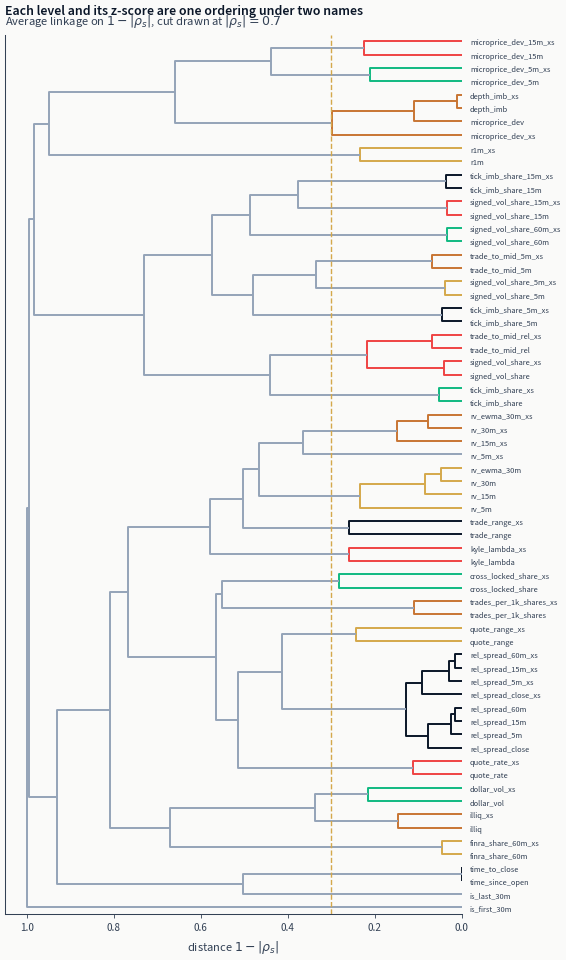

In [31]:
CUT = 0.7
clusters = plot_redundancy_clusters(
    features,
    feature_cols,
    cut=CUT,
    title="Each level and its z-score are one ordering under two names",
    subtitle=rf"Average linkage on $1 - |\rho_s|$, cut drawn at $|\rho_s| = {CUT}$",
    alt=(
        "Dendrogram of all 66 features, leaves labelled on the right. The dominant structure "
        "is that almost every level joins its own cross-sectional z-score at a distance near "
        "zero, so the tree reads as a column of tight pairs. Those pairs then group by "
        "family: the four spread windows with the quote rate and the quote range, the "
        "signed-volume and tick imbalance horizons together, the three nested realized "
        "volatilities with the EWMA, and the microprice deviations with the depth imbalance. "
        "The trade range and the impact regression join the volatility group well above the "
        "cut, and the off-exchange share pairs with its z-score and joins the dollar-volume "
        "and Amihud pair only far above the cut. At the foot, time "
        "since open and time to close form one pair at distance zero, because each is one "
        "minus the other; the last-30-minutes flag joins them around 0.5; and the "
        "first-30-minutes flag stands alone against the root, sharing an ordering with "
        "nothing because it is constant in this matrix."
    ),
)

Cutting the redundancy tree at $|\rho_s| = 0.7$ leaves **28 clusters** across the **66**
columns, so well over half the matrix repeats an ordering another column already carries.
Almost all of that is the level-and-z-score pairing, which is deliberate: the two are one
hypothesis on two scales and a model that can use either is meant to choose. Nothing here
or in `05_evaluation` drops a cluster member: the next stage reports the correlated pairs
and triages each feature on its own, and which member to keep is Chapter 11's choice.

In [32]:
print(f"{len(set(clusters.values()))} clusters over {len(feature_cols)} features at cut {CUT}")

28 clusters over 66 features at cut 0.7


### F6. Persistence and rank stability

The left panel is the autocorrelation of the feature itself, run out to ten rebalances of
the 15-minute schedule. It is estimated within the symbol-session, because every window in
this matrix restarts each morning and a pair of bars either side of a night is not a lag
of anything. The right panel asks the same question of the ordering rather than the level,
between consecutive decisions.

Between them the panels say how much of a feature is left as decisions pass - its own value
on the left, the ordering it puts the names in on the right - and that bears on turnover
without measuring it. What a strategy actually trades depends as well on how many names it
takes on each side, how it weights them, and how the universe itself moves, none of which is
decided here. What can be said is the direction: a feature whose ordering holds ranks roughly
the same names at the next decision, so a strategy reading it has little reason to trade,
and one whose ordering is gone ranks a fresh set, at the cost Chapter 18 prices. Neither
case says anything about whether the feature predicts, which is `05_evaluation`'s question.

The ordering is the half that decides which names get picked, and the two halves can
disagree: the relative spread below keeps almost none of its own level a few rebalances on,
and still puts the names in nearly the order it did at the last one. That is why both are
drawn, and why the order-flow imbalance is carried at four windows rather than one.

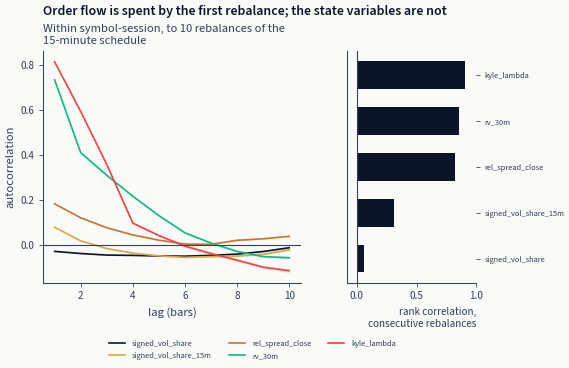

In [33]:
plot_persistence(
    decisions.with_columns(pl.col("timestamp").dt.date().alias("session_date")),
    ["signed_vol_share", PRIMARY_SIGNAL, "rel_spread_close", f"rv_{W['slow']}m", "kyle_lambda"],
    entity=ENTITY,
    max_lag=10,
    decision_dates=DECISION_TIMES.to_list(),
    title="Order flow is spent by the first rebalance; the state variables are not",
    subtitle=f"Within symbol-session, to 10 rebalances of the {DECISION_MINUTES}-minute schedule",
    alt=(
        "Two panels. On the left, autocorrelation against lag in decision bars, one to ten. "
        "Kyle's lambda and the thirty-minute realized volatility start near 0.8 at the first "
        "lag and fall steeply, reaching zero by about the seventh. The relative spread starts "
        "near 0.2 and decays gently to zero. Both order-flow series start below 0.1 and stay "
        "flat along zero for every lag. The bootstrap ribbons are too narrow to "
        "read. On the right, the cross-sectional rank correlation between consecutive "
        "rebalances: Kyle's lambda, the realized volatility and the relative spread form a "
        "tight group between about 0.75 and 0.85, the fifteen-minute signed volume share "
        "reaches about 0.3, and the per-bar one is close to zero."
    ),
)

## G. Emit

The parquet is written with a sidecar recording the digest of its values, its row count and
key columns, and the digest of what it was built from. This stage reads no upstream
case-study artifact - the labels are joined in `05_evaluation`, not here - so the sidecar
records the loaded minute panel alone, restricted to the columns and window actually
consumed. The digest is computed over content rather than file bytes, so row order and
parquet metadata leave it alone and any feature value moves it. That is the property the
registry's own hashes lack: a feature-set *name* reaches the registry, a feature-set
*value* does not.

In [34]:
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=PANEL_KEY,
    written_by="case_studies/nasdaq100_microstructure/03_financial_features.py",
    inputs={"load_nasdaq100_bars": value_digest(bars.select(READ))},
)
print(f"Wrote {display_path(FEATURES_DIR / 'financial.parquet')}, digest {record['digest']}")

Wrote ~/ml4t/artifacts/case_studies/nasdaq100_microstructure/features/financial.parquet, digest e7efd32774c47c3f


## Key takeaways

- **Bound every window by the session, not by the symbol.** An intraday statistic that
  spans a night measures the overnight gap, and on a minute grid that gap is larger than
  anything the feature is meant to see. Making the symbol-session the entity is what makes
  the warmup assertion in D.2 mean the same thing on every row.
- **Measure the session against the schedule, not against the bars that arrived.** The
  realized bar count is a whole-session aggregate, so a feature built on it is a quantity
  nobody had until the session ended - and on an early close the vendor's padded grid makes
  it wrong as well as unknowable.
- **A late-published input needs a lag, however short the delay looks.** Ten seconds is
  small against a one-minute bar and it is not zero, and the cost of deferring a
  sixty-minute average by one bar is nothing.
- **A published name is a specification.** Amihud illiquidity is the average, over a
  window, of the absolute return per dollar traded. A single bar's ratio of the two is a
  different statistic on a different scale, and carrying it under the same name makes it
  incomparable with every other use of the name. Call the library's estimator, or call the
  column something else.
- **Show that withholding later dates changes nothing, rather than reasoning that it
  does.** Rebuilding the matrix on a shorter panel and comparing values catches any
  transform that fits across the sample, including the ones nobody thought to flag.

### Known limitations

- The matrix is at one-minute resolution while the decision grid is fifteen minutes, so a
  model trained on every row sees each 15-minute label fifteen times. The overlap is
  `05_evaluation`'s to price and the downstream models' to weight for; nothing here
  subsamples, because thinning the matrix would throw away the fast families it exists to
  carry.
- `is_first_30m` is identically zero in the emitted matrix. The hour of warmup the impact
  regression needs removes every bar the flag marks, so the opening block of the session -
  the busiest part of the day - is not representable here at all. Section E asserts that
  the column is dead rather than leaving it to be found, but the open remains a gap in what
  this matrix can condition on.
- The vendor emits bars stamped after the exchange has closed on an early-close session, so
  the half-sessions in this window arrive padded out to a full day. Section B drops those
  bars against the published schedule, which is why the matrix is shorter than the raw
  panel on exactly those dates.
- Trade location is assigned against the prevailing quote, so a bar whose quote was stale
  attributes its volume to a side rather than to neither. The staleness cap bounds how long
  that can persist; it does not undo it on the bars inside the cap.
- Every feature here is a rule written in advance. `04_model_based_features` adds the
  features that are themselves model outputs, where the rule is estimated from the data.